In [71]:
import pandas as pd
X=pd.read_csv('./nginx_Xfinal.csv').iloc[:,1:]

X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3353 entries, 0 to 3352
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   component_name                  3353 non-null   object 
 1   component_version               3353 non-null   object 
 2   cpu_limit                       223 non-null    float64
 3   cvm_cpu                         3106 non-null   float64
 4   cvm_cpu_qos                     2129 non-null   object 
 5   cvm_cpu_type                    2870 non-null   object 
 6   cvm_gpu_type                    44 non-null     object 
 7   cvm_memory                      3106 non-null   object 
 8   cvm_os_type                     3094 non-null   object 
 9   cvm_version                     2832 non-null   object 
 10  host_configured_clock_speed     96 non-null     object 
 11  host_cpu_isolation:dpdk         449 non-null    object 
 12  host_cpu_isolation:host         44

In [72]:
threshold=len(X)*0.5
delete_column=[]
for column in X.columns:
    if(X[column].count()<threshold):
        delete_column.append(column)
X.drop(columns=delete_column,inplace=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3353 entries, 0 to 3352
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   component_name     3353 non-null   object 
 1   component_version  3353 non-null   object 
 2   cvm_cpu            3106 non-null   float64
 3   cvm_cpu_qos        2129 non-null   object 
 4   cvm_cpu_type       2870 non-null   object 
 5   cvm_memory         3106 non-null   object 
 6   cvm_os_type        3094 non-null   object 
 7   cvm_version        2832 non-null   object 
 8   platform           3110 non-null   object 
 9   test_name          3353 non-null   object 
 10  tool_name          3353 non-null   object 
 11  tool_version       3353 non-null   object 
dtypes: float64(1), object(11)
memory usage: 314.5+ KB


In [73]:
# import re
# # 判断传入字符串，判断是否包含中文
# zh_pattern = re.compile('[\u4e00-\u9fa5]+')
# zh_index=[]
# for index in range(len(X)):
#     if(re.search(pattern=zh_pattern,string=X["component_version"][index])):
#         zh_index.append(index)
# X.drop(index=zh_index,inplace=True)
# # X.reset_index(drop=True,inplace=True)
# X.info()

In [74]:
y_final=pd.read_csv('./nginx_yfinal.csv').iloc[:,1:3]
y_final["#wrk_qps_avg"].fillna(y_final["#wrk_req_sec_avg"],inplace=True)
y_final.drop(columns=["#wrk_req_sec_avg"],inplace=True)
y_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3353 entries, 0 to 3352
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #wrk_qps_avg  3353 non-null   float64
dtypes: float64(1)
memory usage: 26.3 KB


In [75]:
# y_final=y_final.iloc[X.index]
# y_final.info()


In [76]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
X_encode=ohe.fit_transform(X)
X_encode

<3353x428 sparse matrix of type '<class 'numpy.float64'>'
	with 40236 stored elements in Compressed Sparse Row format>

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encode, y_final, test_size=0.1, random_state=1)

In [78]:
from sklearn.ensemble import RandomForestRegressor
rfg = RandomForestRegressor()
y_pred =rfg.fit(X_train, y_train).predict(X_test)

C:\Users\zhangyangli\AppData\Local\Temp\ipykernel_15624\887598648.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  y_pred =rfg.fit(X_train, y_train).predict(X_test)


In [83]:
y_test_index=y_test.index
y_test.reset_index(drop=True,inplace=True)

In [84]:
y_dis=[]
for i in range(len(y_pred)):
    y_dis.append(y_pred[i]-y_test["#wrk_qps_avg"][i])
y_dis

[163479.37419966696,
 -105650.45066045492,
 102142.31875682439,
 70022.86017142865,
 -82858.88818583358,
 8482.284672619026,
 28090.15780571435,
 -458239.3738133338,
 -146559.63547809527,
 -155844.41399166675,
 -8621.397442857153,
 -193836.36282279715,
 633572.610630238,
 -2845.3221294444083,
 165938.04719071434,
 510009.0108639293,
 83373.73706083477,
 -646011.4728783334,
 -8785.523783333396,
 -833287.9909016667,
 -10524.442939165165,
 181343.62733666674,
 750903.9637166666,
 1146388.2346637305,
 11581.056666667224,
 243617.49703641314,
 679021.1140419848,
 -845070.9033683315,
 716092.8288166672,
 99127.59608159958,
 56534.91706083482,
 -117132.23770107189,
 476349.78278571344,
 -255256.44059238117,
 -811.6420448052086,
 -19943.422822797205,
 183011.57478500006,
 -887836.072708331,
 -158624.2901166015,
 -453364.38010980235,
 18256.861709285702,
 855397.9761816668,
 -20200.460706666672,
 -1010266.261229049,
 -13826.388383095327,
 70987.62037166732,
 229586.04628499947,
 -23539.38246666

In [88]:
pd.DataFrame(data=np.column_stack((y_test_index,y_dis)),columns=["index","dis"]).to_csv('y_dis.csv')

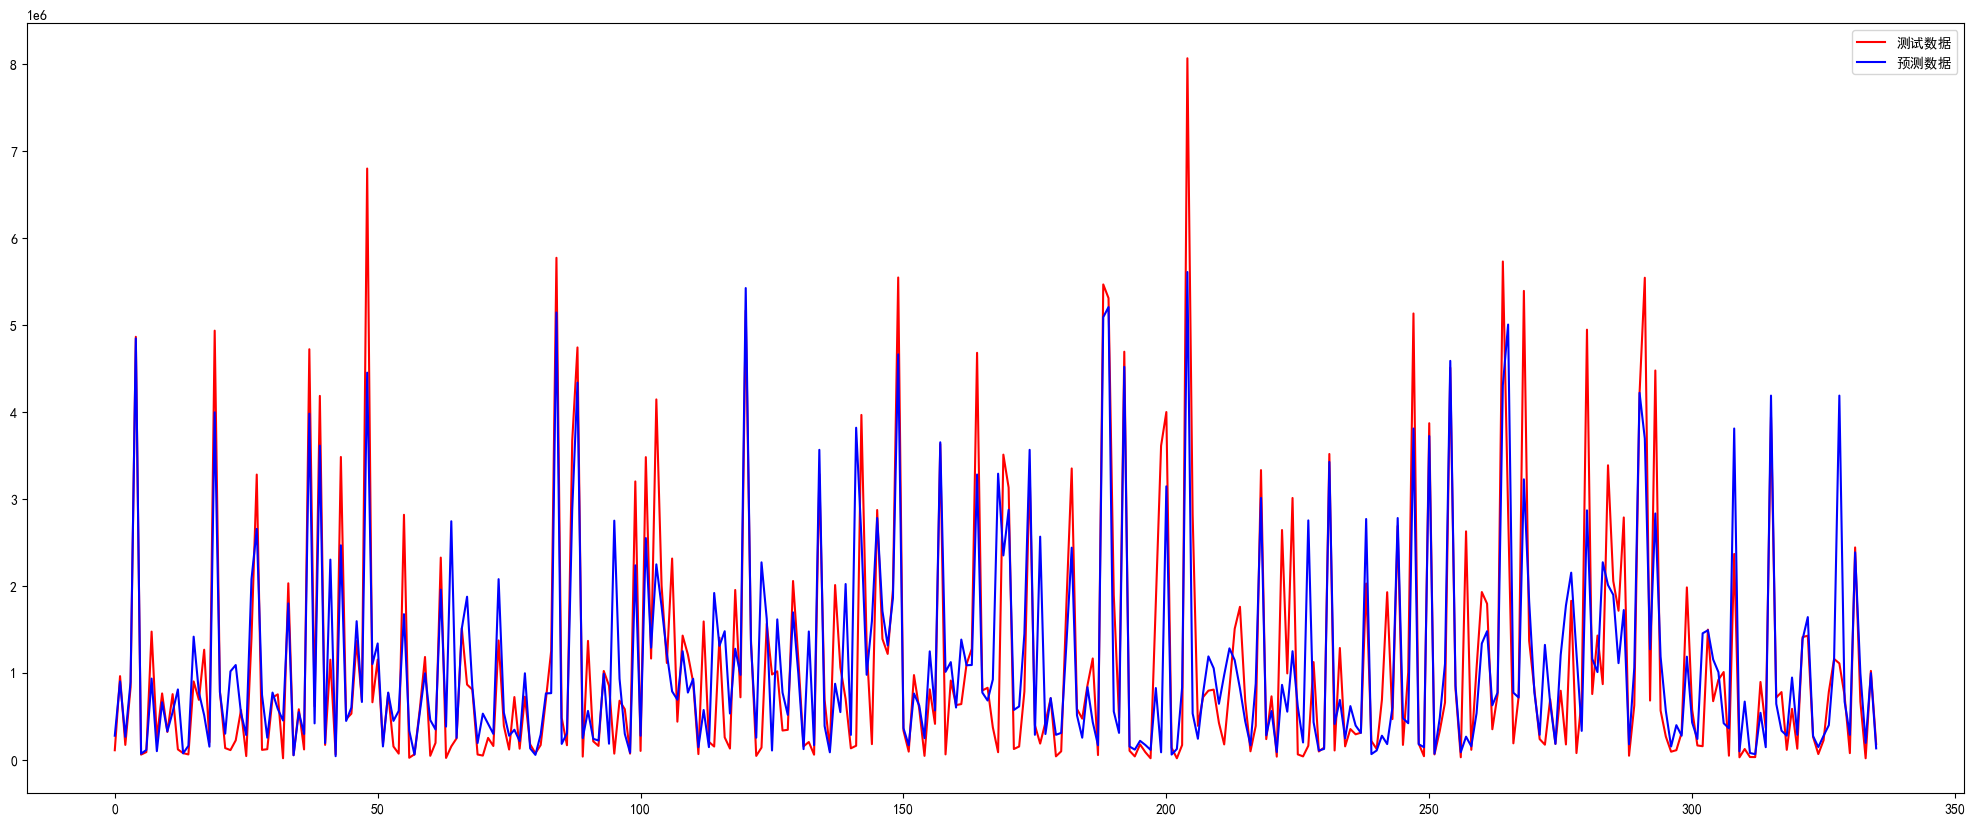

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
plt.figure(figsize=(25,10))
plt.plot(range(len(y_test)), y_test, 'r', label='测试数据')
plt.plot(range(len(y_pred)), y_pred, 'b', label='预测数据')
plt.legend()

In [ ]:
from sklearn import metrics
import numpy as np
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print('MSE:',MSE)
print('RMSE:',RMSE)

MSE: 633052012320.6322
RMSE: 795645.6575138409
